In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

Load Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DSA/DATA SETS/adult_dataset.csv')

In [4]:
#Some columns contains ? and NaN values. to clean that,
df.replace('?', np.nan, inplace=True)

Checking for missing values

In [5]:
#before filling missing values

df.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [6]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', nan,
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [7]:
print(df.isna().sum())

age               2442
workclass         5125
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        5115
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week    2442
native-country    3260
income               0
dtype: int64


In [8]:
#checking numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print (num_cols)

cat_cols = df.select_dtypes(include=['object']).columns
print (cat_cols)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


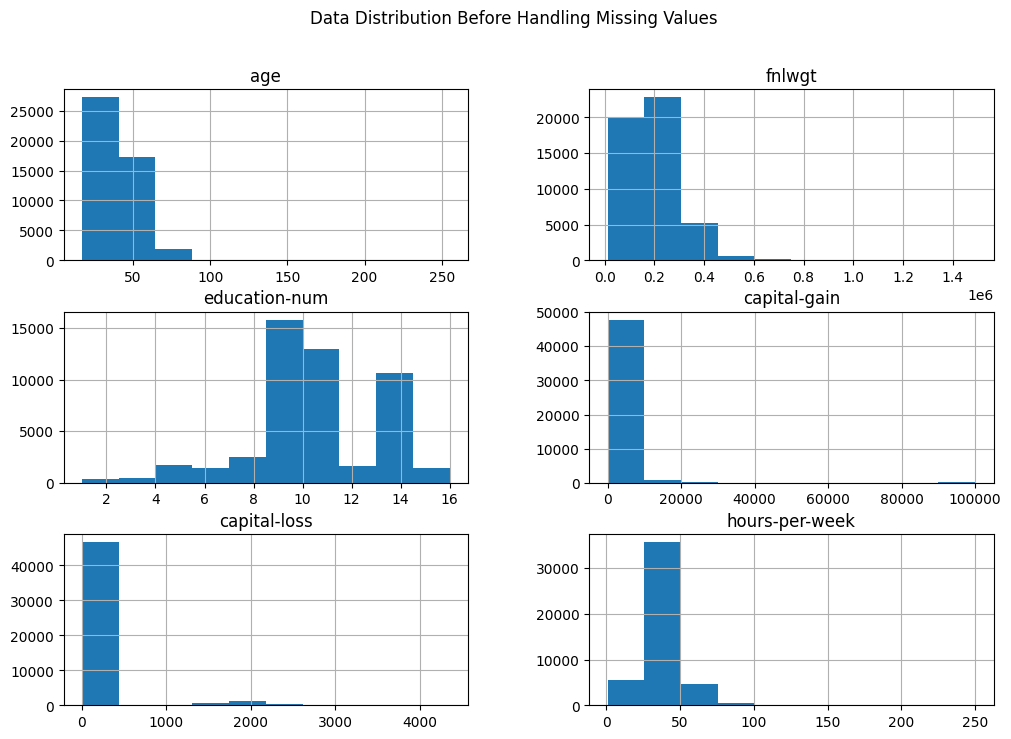

In [9]:
# Numerical columns
num_cols = ['age', 'fnlwgt', 'education-num',
            'capital-gain', 'capital-loss', 'hours-per-week']

# Histograms before handling missing values
df[num_cols].hist(figsize=(12,8))
plt.suptitle("Data Distribution Before Handling Missing Values")

plt.show()

In [10]:
#these graphs shows skewed distribution hence filled with median

Filling Missing Values

In [11]:
#Filling numerical columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [13]:
#after filling numerical missing values
df.isna().sum()

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [14]:
#filling Categorical Columns

In [15]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [17]:
df.isna().sum()

#after filling categorical missing values

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Remove Income Column

In [18]:
#since its an unsupervised learning, should not train using labels

X = df.drop('income', axis=1)

Detect and Treat Outliers

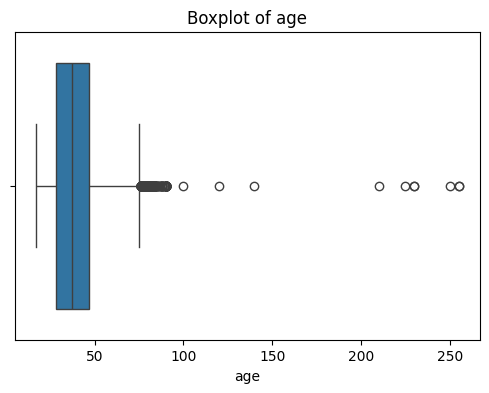

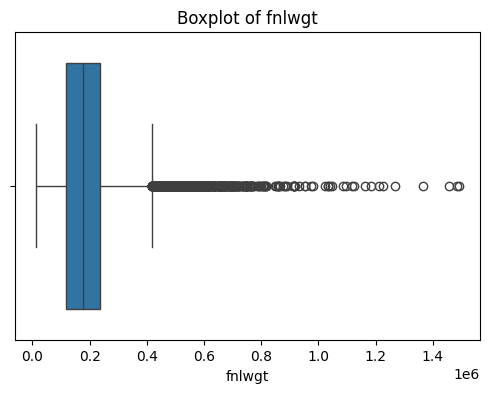

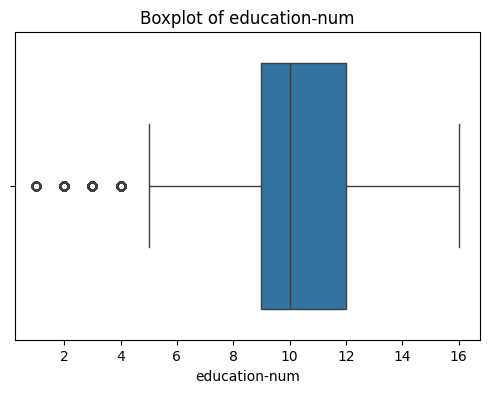

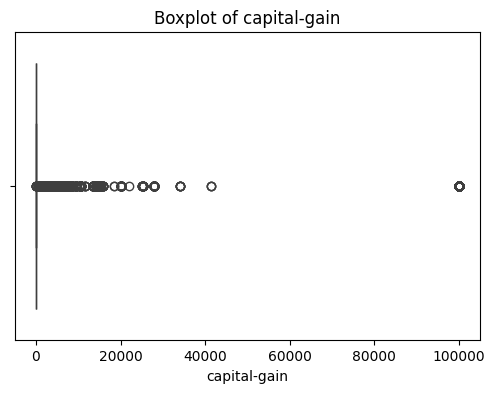

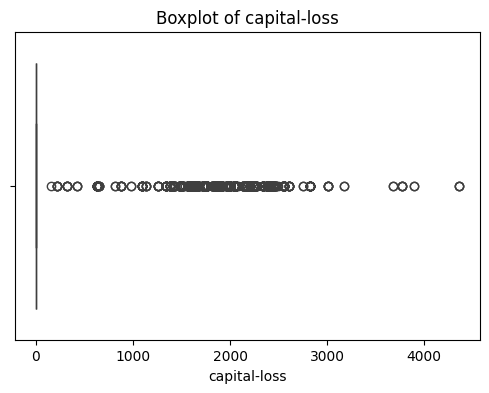

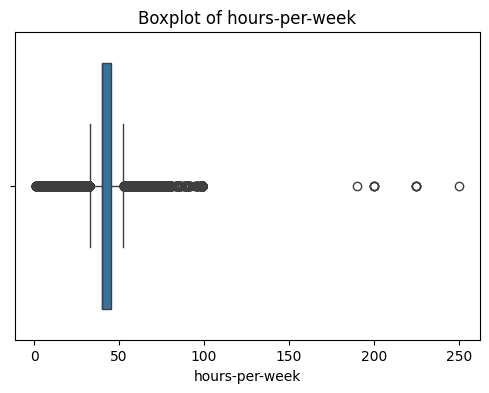

In [19]:
#boxplot
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

Using IQR Method

In [20]:
# Calculate Q1, Q3, IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

# Lower and Upper limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"\nColumn: {col}")
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Limit :", lower)
print("Upper Limit :", upper)


Column: hours-per-week
Q1 : 40.0
Q3 : 45.0
IQR : 5.0
Lower Limit : 32.5
Upper Limit : 52.5


###Encoding Categorical

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
#Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = df.copy()

for col in cat_cols:
    # Adding .astype(str) ensures the encoder doesn't crash on mixed types
    df_encoded[col] = le.fit_transform(df[col].astype(str))

Feature Scaling

In [23]:
#Clustering algorithms are distance-based. Features with larger values dominate the distance calculation.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Exploratory Data Analysis (EDA)

###Visualisation of Distribution Analysis

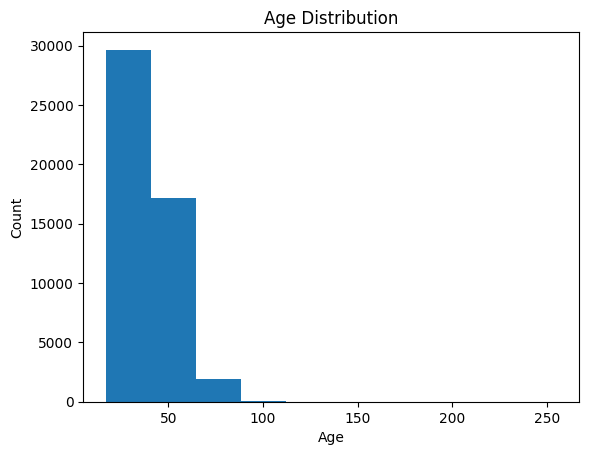

In [24]:
plt.hist(df['age'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [25]:
#Insights from graph

# Most people are between 25–50 years.
# Very young and very old individuals are fewer.

##Hours Per Week Distribution

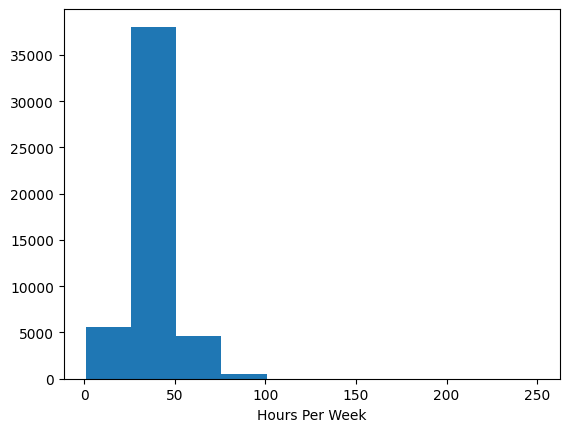

In [26]:
plt.hist(df['hours-per-week'])
plt.xlabel('Hours Per Week')
plt.show()

In [27]:
#Insights from graph

# Majority work around 40 hours/week.
# Some extreme values exist.

##Correlation Analysis

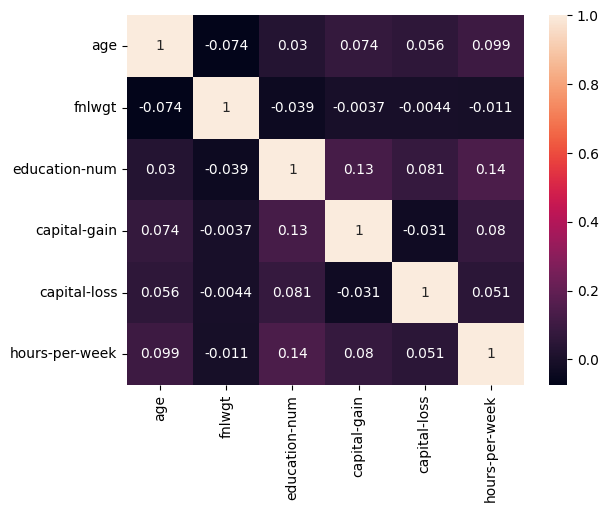

In [28]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [29]:
#Insights from graph

# education-num positively relates to income potential
# capital-gain and capital-loss are highly skewed
# hours-per-week slightly correlates with earnings

##Dimensionality Reduction

###PCA for Visualization

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 0.87350857,  2.51285809],
       [ 3.04847866,  0.51192318],
       [-0.83320769, -0.4247878 ],
       ...,
       [ 1.87952033,  0.72762393],
       [-0.26205831,  0.70506222],
       [ 3.72767377,  0.66182419]])

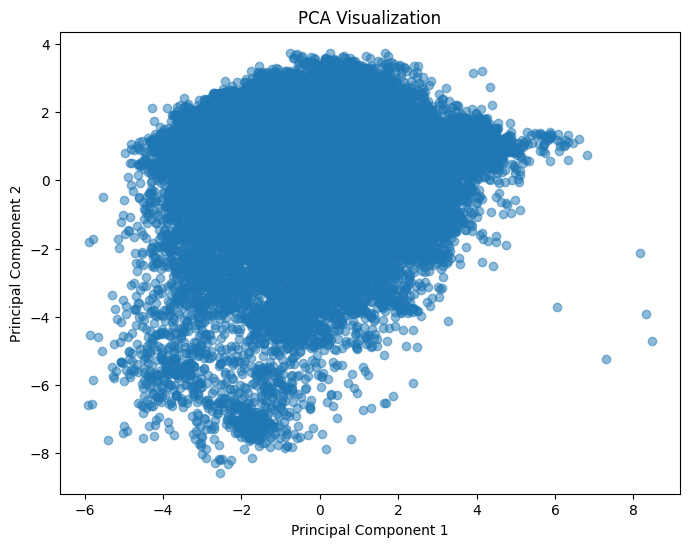

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

In [31]:
#Insights

# Similar points appear closer together
# Different groups separate naturally
# Helps understand cluster structure

#Clustering

##KMeans Clustering

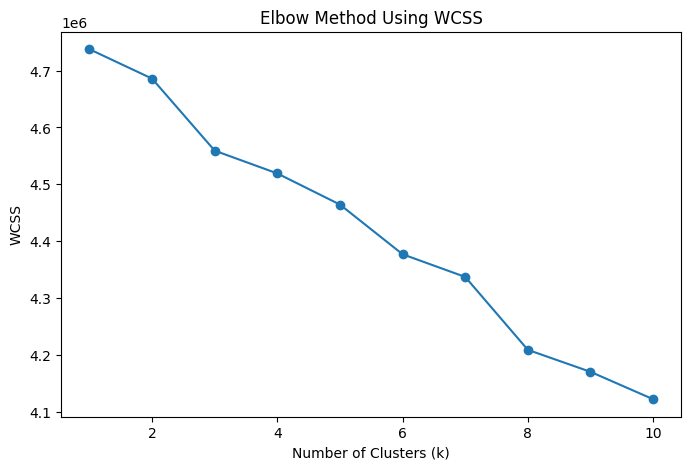

In [32]:
#Choosing K using Elbow Method

# WCSS = Within Cluster Sum of Squares
wcss = []

# Calculate WCSS for different k values
for k in range(1,11):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.title('Elbow Method Using WCSS')

plt.show()

In [33]:
# The graph showed a slight bend around k = 3 to 4.
# Therefore, k = 4 was selected for clustering.

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_scaled)

###Evaluate Clustering Using Silhouette Score

In [35]:
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.051271157954066955


In [36]:
# Interpretation
# Silhouette score measures cluster quality.
# Higher score indicates:
# better separation
# better compactness

# The obtained score indicates acceptable clustering performance for this dataset.

###Visualize Clusters Using PCA

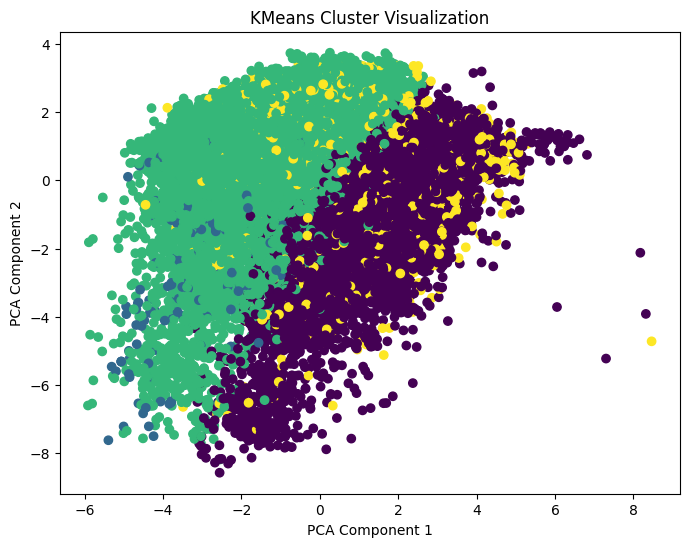

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.title('KMeans Cluster Visualization')

plt.show()

In [38]:
#Insights from Plot

# Different socioeconomic groups are visible in the reduced 2D space.
# Some overlap exists because real-world census data is complex and high-dimensional.

###Agglomerative Clustering

In [39]:
# Add cluster labels to dataframe

df['cluster'] = labels

In [40]:
# Check first few rows

df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,cluster
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K,2
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K,0


In [41]:
# Count number of records in each cluster

print(df['cluster'].value_counts())

cluster
2    24071
0    21052
3     3485
1      234
Name: count, dtype: int64


In [42]:
# Cluster profiling using numerical columns

df.groupby('cluster').mean(numeric_only=True)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
cluster,,,,,,
0,43.377826,186150.204494,10.277076,2039.079850,0.134809,43.432833
1,42.824786,196650.307692,7.512821,83.649573,41.700855,33.243590
2,34.137759,192747.590254,9.793237,366.530140,4.704832,37.624569
3,40.207747,189124.286944,11.015782,268.232712,1190.227260,42.096700


In [43]:
# Compare clusters with income

pd.crosstab(df['cluster'], df['income'])

income,<=50K,<=50K.,>50K,>50K.
cluster,,,,
0,8124,4003,5971,2954
1,142,90,0,2
2,15188,7623,858,402
3,1266,719,1012,488


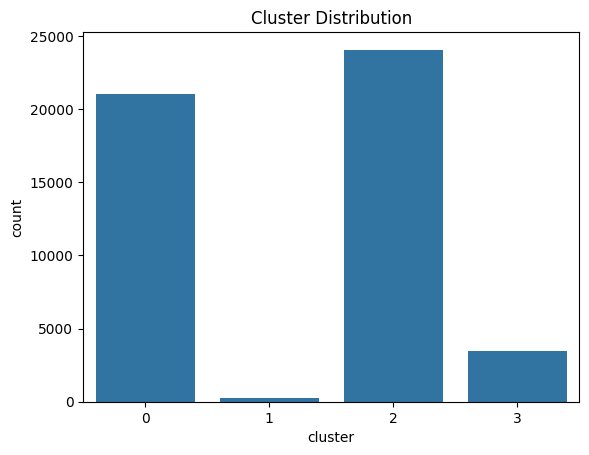

In [44]:
# Visualize cluster distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cluster', data=df)

plt.title('Cluster Distribution')

plt.show()

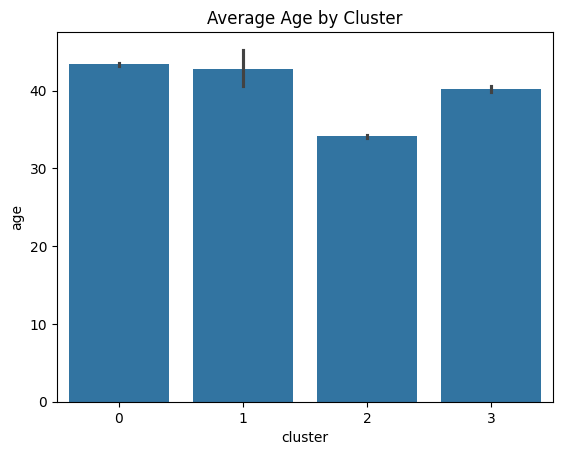

In [45]:
# Visualize average age per cluster

sns.barplot(x='cluster', y='age', data=df)

plt.title('Average Age by Cluster')

plt.show()

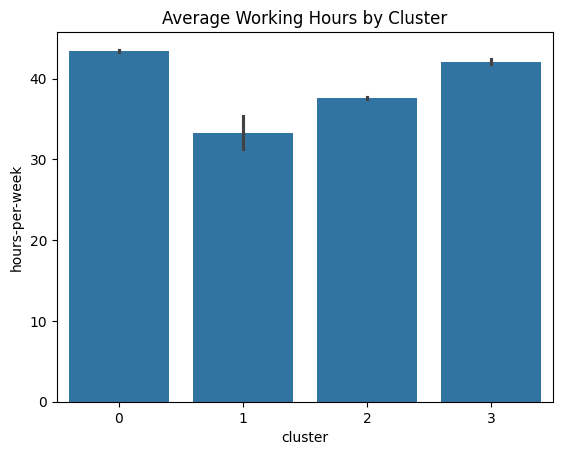

In [46]:
# Visualize average hours-per-week per cluster

sns.barplot(x='cluster', y='hours-per-week', data=df)

plt.title('Average Working Hours by Cluster')

plt.show()

###Agglomerative Clustering

In [47]:
# Take smaller sample

X_sample = X_scaled[:5000]

In [48]:
agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X_sample)

In [49]:
# PCA sample for visualization

X_pca_sample = X_pca[:5000]

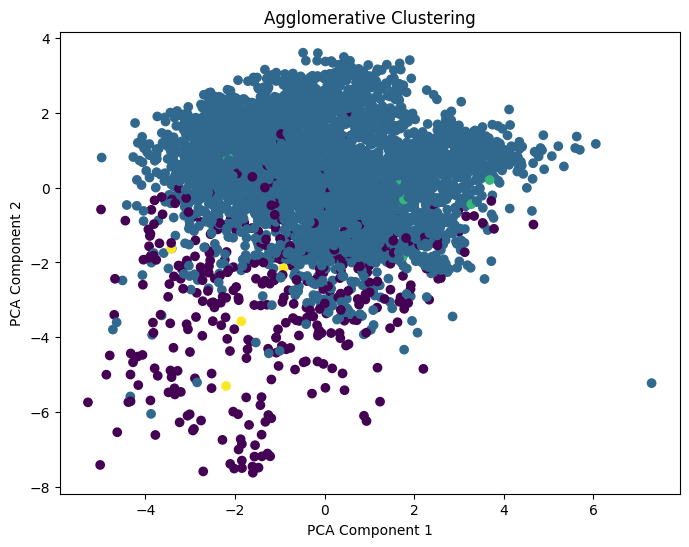

In [50]:
# Visualize Agglomerative Clusters

plt.figure(figsize=(8,6))

plt.scatter(X_pca_sample[:,0],
            X_pca_sample[:,1],
            c=agg_labels)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.title('Agglomerative Clustering')

plt.show()

In [51]:
# Silhouette Score for Agglomerative Clustering


agg_score = silhouette_score(X_sample, agg_labels)

print("Agglomerative Silhouette Score:", agg_score)

Agglomerative Silhouette Score: 0.4934026683467856


In [52]:
# Compare KMeans and Agglomerative Scores

print("KMeans Silhouette Score:", score)
print("Agglomerative Silhouette Score:", agg_score)

KMeans Silhouette Score: 0.051271157954066955
Agglomerative Silhouette Score: 0.4934026683467856


In [53]:
# Final Cluster Profiling

df.groupby('cluster').mean(numeric_only=True)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
cluster,,,,,,
0,43.377826,186150.204494,10.277076,2039.079850,0.134809,43.432833
1,42.824786,196650.307692,7.512821,83.649573,41.700855,33.243590
2,34.137759,192747.590254,9.793237,366.530140,4.704832,37.624569
3,40.207747,189124.286944,11.015782,268.232712,1190.227260,42.096700


In [54]:
# Income distribution across clusters

pd.crosstab(df['cluster'], df['income'])

income,<=50K,<=50K.,>50K,>50K.
cluster,,,,
0,8124,4003,5971,2954
1,142,90,0,2
2,15188,7623,858,402
3,1266,719,1012,488


In [55]:
# Education level across clusters

pd.crosstab(df['cluster'], df['education'])

education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
cluster,,,,,,,,,,,,,,,,
0,517,511,188,120,259,535,341,615,918,3846,393,6934,1439,27,575,3834
1,7,18,8,14,20,17,15,3,5,10,1,88,1,2,0,25
2,824,1238,449,107,213,372,384,799,898,3345,126,7958,946,52,157,6203
3,41,45,12,6,17,31,16,184,240,824,74,804,271,2,102,816


In [56]:
# Occupation distribution across clusters

pd.crosstab(df['cluster'], df['occupation'])

occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
cluster,,,,,,,,,,,,,,
0,1354,6,3571,3296,841,676,1337,973,0,4783,557,2262,0,1396
1,0,0,0,0,0,0,0,0,234,0,0,0,0,0
2,3803,8,1974,2052,544,1258,1442,3599,0,5591,342,2712,0,746
3,172,1,246,423,45,43,95,85,0,595,44,257,1383,96


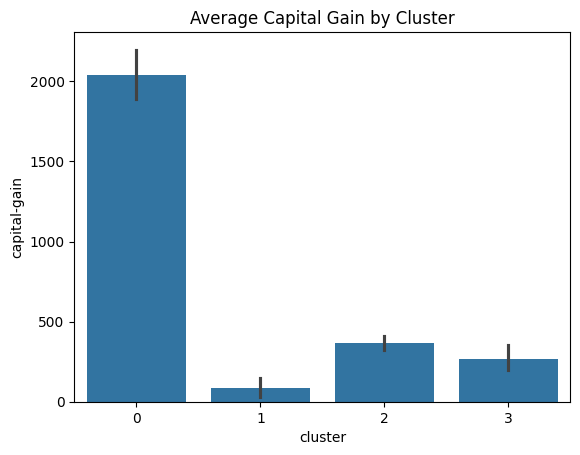

In [57]:
# Average capital gain by cluster

sns.barplot(x='cluster',
            y='capital-gain',
            data=df)

plt.title('Average Capital Gain by Cluster')

plt.show()

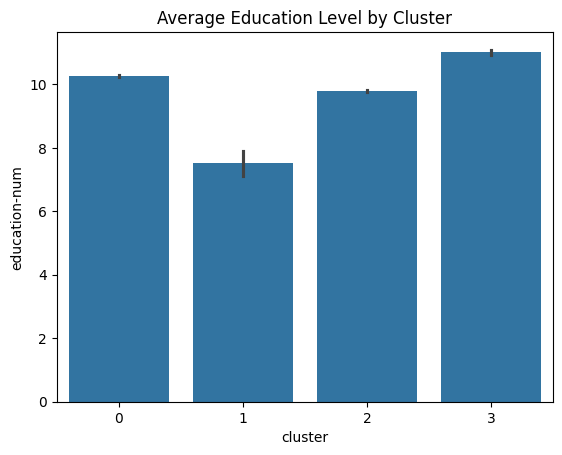

In [58]:
# Average education number by cluster

sns.barplot(x='cluster',
            y='education-num',
            data=df)

plt.title('Average Education Level by Cluster')

plt.show()

In [59]:
# Save final dataframe with cluster labels

df.to_csv('clustered_adult_dataset.csv', index=False)

Interpretation of Clusters
Cluster 0 – Highly Educated Professionals

Characteristics:

Higher education level
Higher capital gain
Stable working hours

Possible Group:

Higher income professionals

Cluster 1 – Working Class Population

Characteristics:

Moderate education
Regular full-time work
Private sector occupations

Cluster 2 – Economically Vulnerable Group

Characteristics:

Lower education
Lower working hours
Lower financial indicators

Possible Needs:

Welfare support
Skill development programs

Cluster 3 – Senior / Low Workforce Participation Group

Characteristics:

Higher age
Reduced working hours
Lower workforce participation

Final Insights

The clustering analysis successfully identified hidden socioeconomic groups within the census dataset.

Important factors influencing clustering:

Education level
Work hours
Occupation
Capital gain/loss
Age

Conclusion

This case study successfully applied unsupervised learning techniques
to identify hidden socioeconomic groups within the Adult Census dataset.

The following steps were performed:

- Data cleaning
- Missing value handling
- Outlier detection
- Encoding categorical variables
- Feature scaling
- PCA dimensionality reduction
- KMeans clustering
- Agglomerative clustering

The clustering algorithms identified meaningful population segments
based on education, occupation, working hours, age, and financial indicators.

These findings can support:
- policy planning
- welfare program design
- employment analysis
- socioeconomic research